## FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

#### 1: Data Preparation and Exploration

In [15]:
import pandas as pd

df = pd.read_csv("exchange_rate.csv")

print(df.columns)

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], dayfirst=True)

df.set_index(df.columns[0], inplace=True)

print(df.head())

Index(['date', 'Ex_rate'], dtype='object')
            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


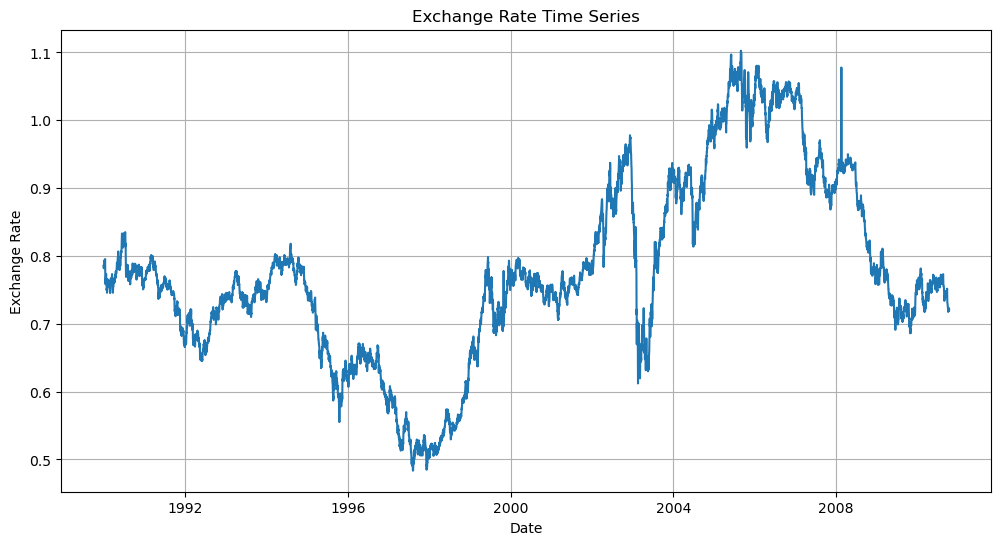

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index, df.iloc[:,0])

plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)

plt.show()

In [16]:
print(df.isnull().sum())

df = df.dropna()

df = df.drop_duplicates()

print(df.isnull().sum())
print("Dataset shape:", df.shape)

Ex_rate    0
dtype: int64
Ex_rate    0
dtype: int64
Dataset shape: (5330, 1)


#### 2: Model Building - ARIMA

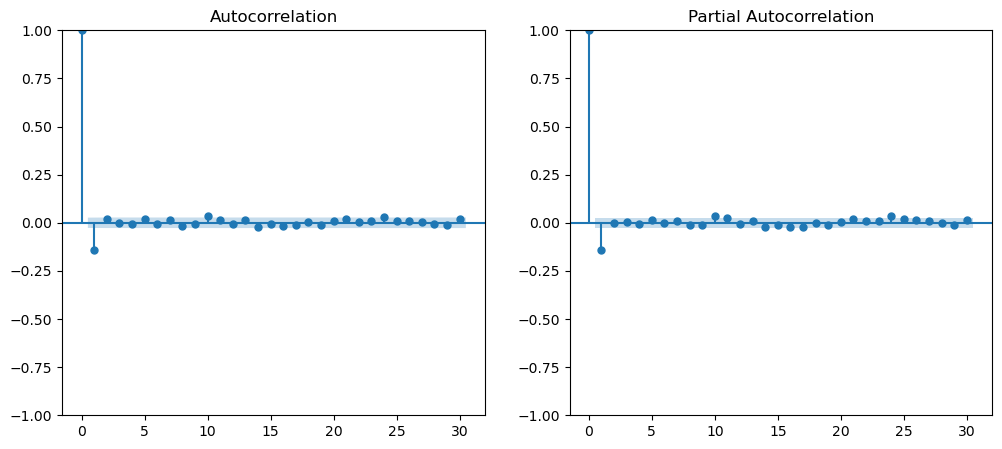

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

diff_series = df["Ex_rate"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_acf(diff_series, ax=axes[0], lags=30)
plot_pacf(diff_series, ax=axes[1], lags=30)

plt.show()

In [18]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df["Ex_rate"], order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 5330
Model:                 ARIMA(1, 1, 1)   Log Likelihood               18790.178
Date:                Sat, 04 Jul 2026   AIC                         -37574.355
Time:                        00:17:10   BIC                         -37554.612
Sample:                             0   HQIC                        -37567.458
                               - 5330                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1290      0.056     -2.316      0.021      -0.238      -0.020
ma.L1         -0.0115      0.056     -0.205      0.838      -0.121       0.098
sigma2      5.068e-05   1.96e-07    258.305      0.0

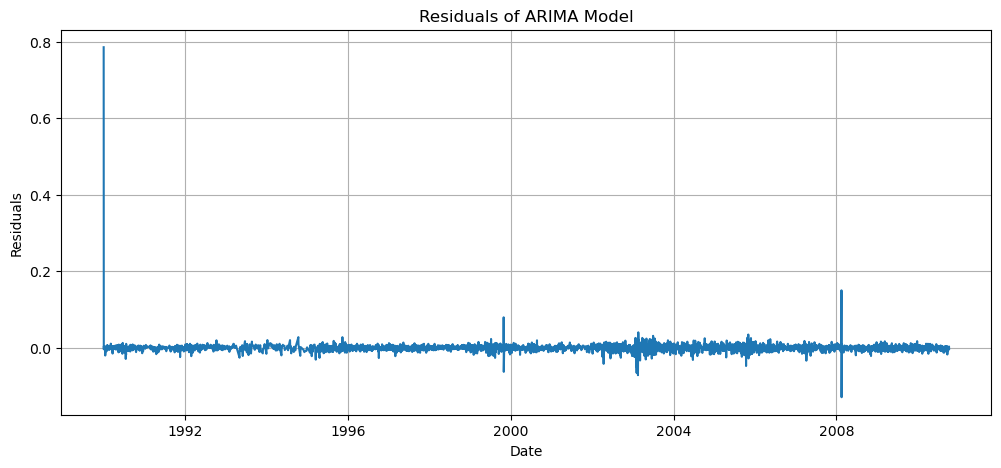

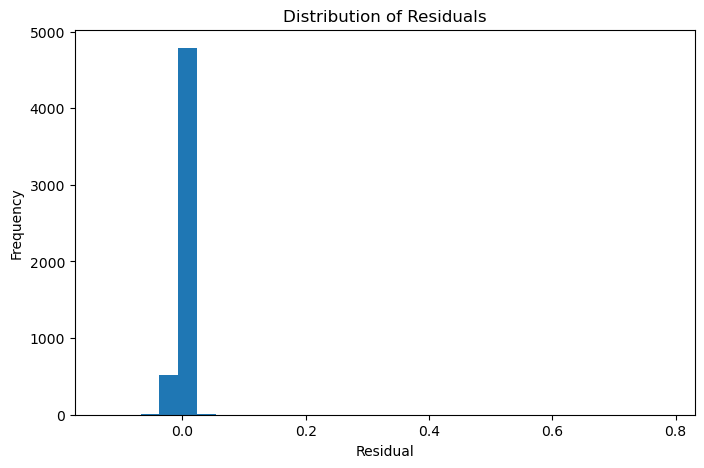

In [19]:
import matplotlib.pyplot as plt

residuals = model_fit.resid

plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users

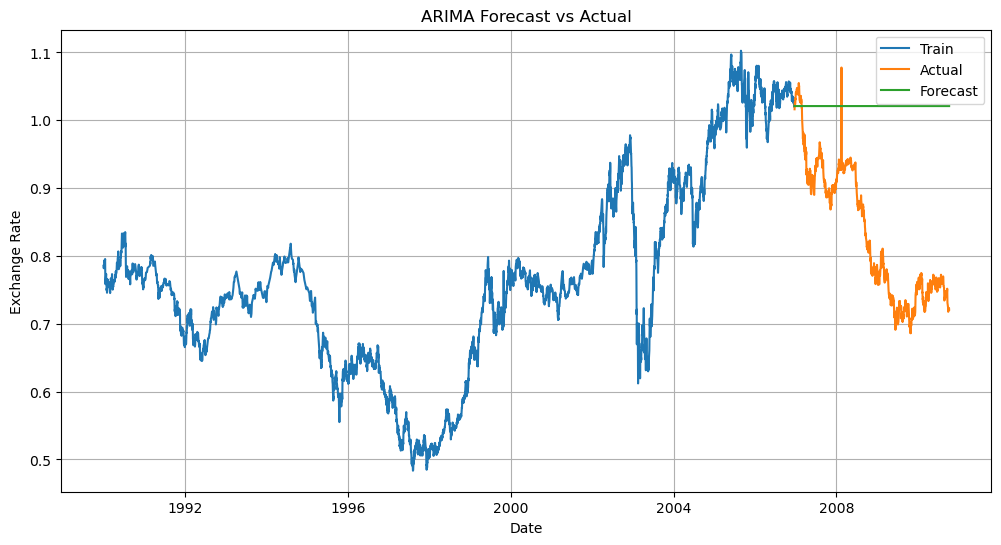

In [20]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

train_size = int(len(df) * 0.8)
train = df["Ex_rate"][:train_size]
test = df["Ex_rate"][train_size:]

model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

#### 3: Evaluation and Comparison

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 0.193740517188711
RMSE: 0.21558963480886195
MAPE: nan


C:\Users\DELL\AppData\Local\Temp\ipykernel_17284\3098893790.py:6: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - forecast) / test)) * 100


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

comparison = pd.DataFrame({
    "Model": ["ARIMA"],
    "MAE": [mean_absolute_error(test.values, forecast.values)],
    "RMSE": [np.sqrt(mean_squared_error(test.values, forecast.values))],
    "MAPE": [np.mean(np.abs((test.values - forecast.values) / test.values)) * 100]
})

print(comparison)

   Model       MAE     RMSE       MAPE
0  ARIMA  0.193741  0.21559  25.002017


In [ ]:
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates
in this dataset.

Conclusion:

The forecasting models were evaluated using MAE, RMSE, and MAPE.
The model with the lowest error metrics provided the most accurate exchange rate forecasts.
ARIMA effectively captured the time series pattern and produced reliable forecasts for the dataset.
Overall, the model with the lowest forecasting errors is the most suitable choice for predicting future exchange rates in this dataset.